# 1.758 especies de mariposas cambiaron de sitio. El 65% tiene un solo registro detrás

Un equipo revisó 567 estudios en quince idiomas y les sumó 68 evaluaciones de expertos para armar el inventario más grande que existe de mariposas que se corrieron de lugar. Salieron 1.758 especies en 105 países. El 81,2% ganó terreno.

Y después está la letra pequeña: dos tercios de esas especies entraron a la lista por un solo registro, de un solo estudio, en un solo país.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** [Extensive climate-induced range shifts in butterflies across the globe](https://doi.org/10.1038/s41559-026-03117-y) · *Nature Ecology & Evolution*, 5 de agosto de 2026
**DOI:** [10.1038/s41559-026-03117-y](https://doi.org/10.1038/s41559-026-03117-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-06-mariposas-desplazamientos-clima/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/I1Gz748RZZI)

## Qué compilaron

Nadie salió al campo con una red. Este trabajo se hizo en la biblioteca: 567 estudios publicados en quince idiomas, más 68 evaluaciones de expertos que aportaron datos sin publicar. De ahí salieron 6.182 registros de desplazamiento para 1.758 especies de mariposas en 105 países y territorios.

Son el 9,1% de las 19.327 especies de mariposas conocidas. Es la foto más grande que hay hoy — y sigue siendo la foto de una esquina.

Una aclaración que conviene tener a mano desde ya: el conjunto de datos (el *dataset*) registra **si** una especie se movió y **en qué dirección**, no **cuánto**. Los autores dicen por escrito que no pudieron compilar tasas estandarizadas. Aquí no hay kilómetros ni metros de altitud.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_ESPECIES_DATASET   = 1758     # especies con desplazamiento documentado
N_ESPECIES_CONOCIDAS = 19327    # especies de mariposas descritas en el mundo
ANIO_CORTE           = 2010     # umbral para "estudios recientes"
VENTANA_DECLARADA    = 1991     # inicio de la ventana de búsqueda del paper

FUENTE = ('Fuente: Chowdhury et al. (2026), Nature Ecology & Evolution  |  '
          'Datos: Supplementary Information del mismo DOI')

COLOR_DATOS       = '#2563EB'   # azul CaM
COLOR_ALERTA      = '#DC2626'   # rojo
COLOR_SECUNDARIO  = '#059669'   # emerald
COLOR_REFERENCIA  = '#D97706'   # amber
COLOR_CONTEXTO    = '#BBBBBB'   # gris

# ── Setup ─────────────────────────────────────────────────────
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'


def num_es(x, dec=1):
    """Número al estilo español: miles con punto, decimales con coma."""
    s = f'{x:,.{dec}f}'
    return s.replace(',', '@').replace('.', ',').replace('@', '.')



style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ── Carga ─────────────────────────────────────────────────────
especies   = pd.read_csv('datos/especies_familia.csv')
familias   = pd.read_csv('datos/familias_resumen.csv')
tipos      = pd.read_csv('datos/tipos_desplazamiento.csv')
regional   = pd.read_csv('datos/composicion_regional.csv')
clima_tipo = pd.read_csv('datos/amenaza_clima_por_tipo.csv')
paises     = pd.read_csv('datos/paises_destacados.csv')
evidencia  = pd.read_csv('datos/concentracion_evidencia.csv')
anios      = pd.read_csv('datos/estudios_por_anio.csv')

# Serie desagregada de años: un valor por estudio (461 de los 567)
anios_flat = np.repeat(anios['anio'].values, anios['n_estudios'].values)

print('ESPECIES')
print(f'  filas: {len(especies)}  |  únicas: {especies.especie.nunique()}  |  '
      f'familias: {especies.familia.nunique()}')
print(f'  cobertura de la diversidad conocida: '
      f'{100 * N_ESPECIES_DATASET / N_ESPECIES_CONOCIDAS:.1f}%')

print('\nTIPOS DE DESPLAZAMIENTO (una especie puede estar en varios)')
for _, r in tipos.iterrows():
    print(f'  {r.tipo:28s} {r.n_especies:5d} especies  '
          f'({r.pct_del_total_1758:4.1f}%)   en {r.n_paises:3d} países')
suma_tipos = int(tipos.n_especies.sum())
print(f'  {"SUMA":28s} {suma_tipos:5d}  →  '
      f'{suma_tipos - N_ESPECIES_DATASET} solapamientos sobre {N_ESPECIES_DATASET} especies')

print('\nFAMILIAS')
for _, r in familias.iterrows():
    print(f'  {r.familia:14s} {r.n_especies:4d}  ({r.pct_dataset:5.2f}%)')
print(f'  top-3 = {familias.pct_dataset.head(3).sum():.1f}% del dataset')

print('\nAÑO DE LOS ESTUDIOS  (subconjunto: 461 de 567 = 81,3%)')
print(f'  mediana {np.median(anios_flat):.0f}  |  media {anios_flat.mean():.1f}  |  '
      f'IQR {np.percentile(anios_flat, 25):.0f}–{np.percentile(anios_flat, 75):.0f}')
print(f'  rango {anios_flat.min()}–{anios_flat.max()}  |  '
      f'desde {ANIO_CORTE}: {100 * (anios_flat >= ANIO_CORTE).mean():.1f}%  |  '
      f'anteriores a {VENTANA_DECLARADA}: {(anios_flat < VENTANA_DECLARADA).sum()}')

print('\nCONCENTRACIÓN DE LA EVIDENCIA')
for _, r in evidencia.iterrows():
    print(f'  {r.metrica:38s} {r.pct_de_1758:5.1f}%   [{r.fuente}]')

ESPECIES
  filas: 1758  |  únicas: 1758  |  familias: 6
  cobertura de la diversidad conocida: 9.1%

TIPOS DE DESPLAZAMIENTO (una especie puede estar en varios)
  expansion_horizontal          1427 especies  (81.2%)   en  97 países
  contraccion_horizontal         480 especies  (27.3%)   en  27 países
  desplazamiento_elevacional     381 especies  (21.7%)   en  18 países
  SUMA                          2288  →  530 solapamientos sobre 1758 especies

FAMILIAS
  Nymphalidae     657  (37.37%)
  Hesperiidae     394  (22.41%)
  Lycaenidae      368  (20.93%)
  Pieridae        172  ( 9.78%)
  Papilionidae     87  ( 4.95%)
  Riodinidae       80  ( 4.55%)
  top-3 = 80.7% del dataset

AÑO DE LOS ESTUDIOS  (subconjunto: 461 de 567 = 81,3%)
  mediana 2014  |  media 2012.4  |  IQR 2008–2018
  rango 1948–2024  |  desde 2010: 71.8%  |  anteriores a 1991: 4

CONCENTRACIÓN DE LA EVIDENCIA
  un_solo_registro_un_estudio_un_pais     65.0%   [pct del paper; n derivado]
  mas_de_diez_registros_independiente

## Aquí está.

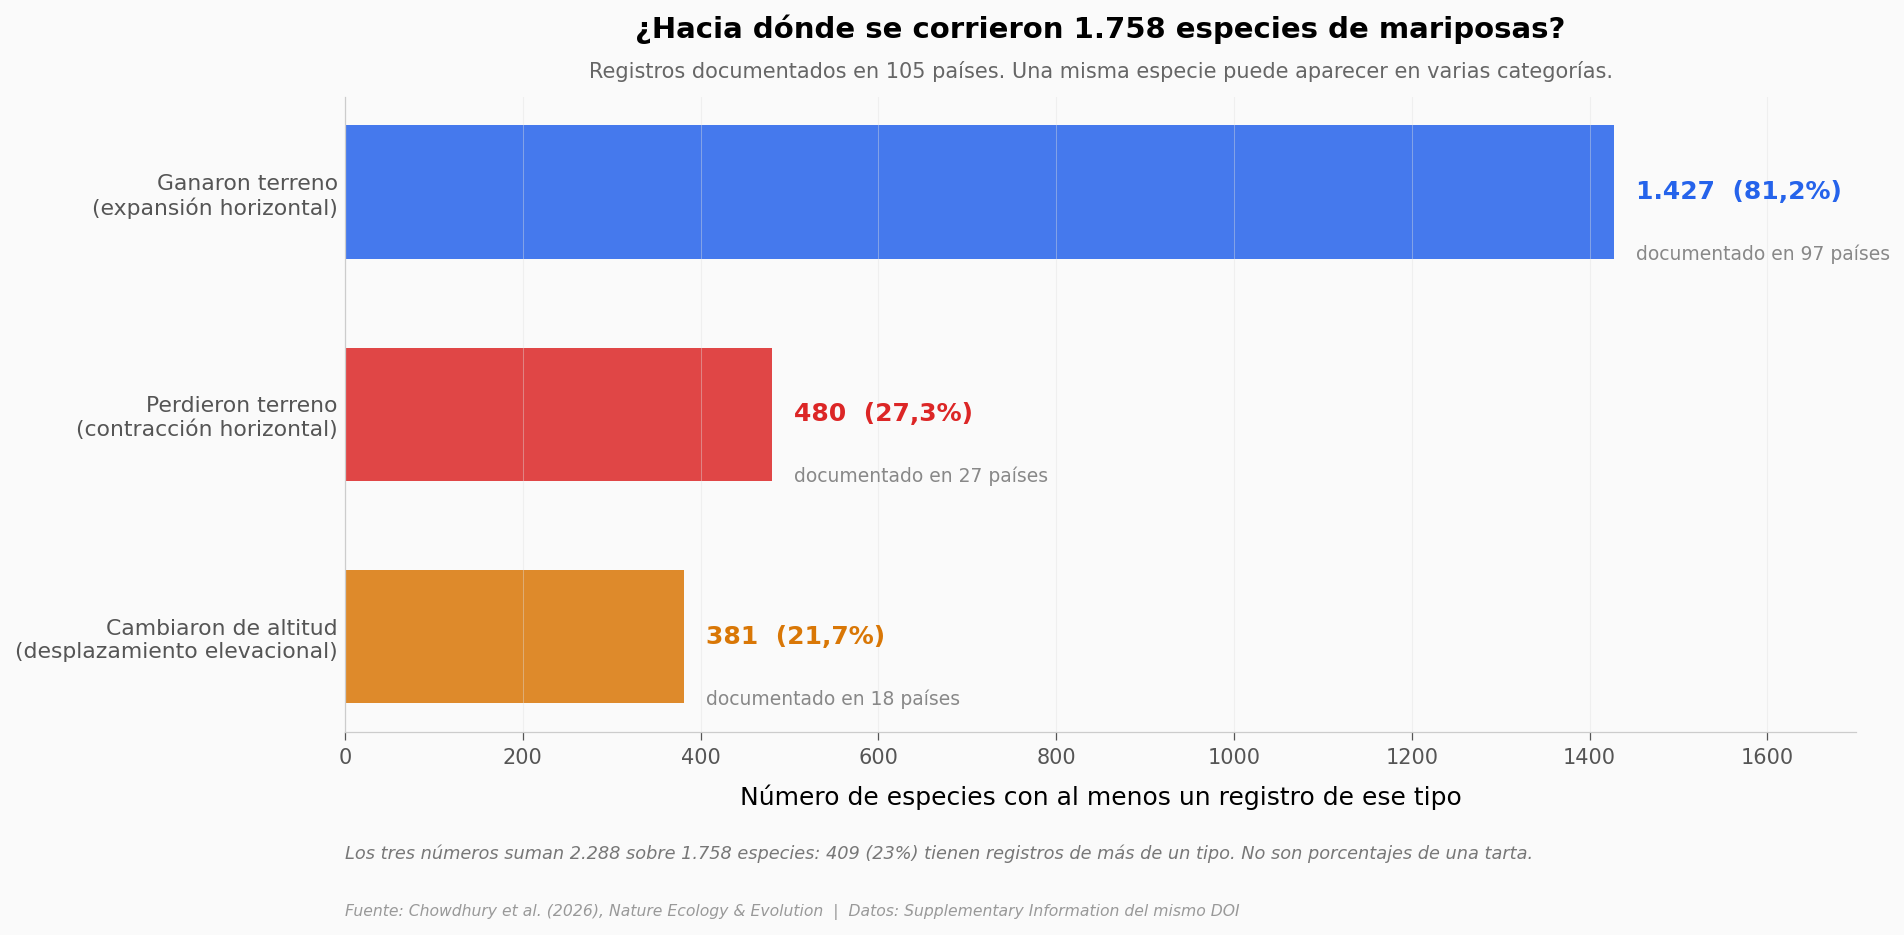

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

etiquetas = ['Ganaron terreno\n(expansión horizontal)',
             'Perdieron terreno\n(contracción horizontal)',
             'Cambiaron de altitud\n(desplazamiento elevacional)']
colores = [COLOR_DATOS, COLOR_ALERTA, COLOR_REFERENCIA]
y = np.arange(len(tipos))[::-1]

ax.barh(y, tipos.n_especies, color=colores, alpha=0.85, height=0.6)

for yi, (_, r), c in zip(y, tipos.iterrows(), colores):
    ax.text(r.n_especies + 25, yi,
            f'{num_es(r.n_especies, 0)}  ({num_es(r.pct_del_total_1758)}%)',
            va='center', ha='left', fontsize=12, fontweight='bold', color=c)
    ax.text(r.n_especies + 25, yi - 0.28,
            f'documentado en {r.n_paises} países',
            va='center', ha='left', fontsize=9, color='#888888')

ax.set_yticks(y)
ax.set_yticklabels(etiquetas, fontsize=10.5)
ax.set_xlim(0, 1700)
ax.set_xlabel('Número de especies con al menos un registro de ese tipo')
ax.grid(axis='x', alpha=0.4)
ax.grid(axis='y', visible=False)

ax.set_title('¿Hacia dónde se corrieron 1.758 especies de mariposas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Registros documentados en 105 países. Una misma especie puede aparecer en varias categorías.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

nota = (f'Los tres números suman {num_es(tipos.n_especies.sum(), 0)} sobre '
        f'{num_es(N_ESPECIES_DATASET, 0)} especies: 409 (23%) tienen registros de más de '
        'un tipo. No son porcentajes de una tarta.')
ax.text(0.0, -0.20, nota, transform=ax.transAxes,
        fontsize=8.5, color='#777777', style='italic')

ax.text(0.0, -0.29, FUENTE, transform=ax.transAxes,
        fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tipos_desplazamiento.png', dpi=200, bbox_inches='tight')
plt.show()

La expansión manda: 1.427 especies (81,2%) tienen al menos un registro de haber ganado terreno. La contracción aparece en 480 (27,3%) y el cambio de altitud en 381 (21,7%).

Los tres números suman 2.288 sobre 1.758 especies, y eso no es un error de cuentas: 409 especies (23%) tienen registros de más de un tipo. Cuatro de ellas —*Vanessa cardui*, *Nymphalis antiopa*, *Gonepteryx rhamni* y *Anthocharis cardamines*— tienen registros de **subir y de bajar** en altitud, según dónde se las mire. Una mariposa no hace una sola cosa en todo el planeta.

La otra asimetría está en el reparto por países: la expansión aparece en 97, la contracción en 27, la altitud en 18. Ganar terreno no solo es más frecuente en la lista: también está repartido en muchos más sitios.

Los récords individuales dan la escala de lo desigual que es esta evidencia. *Araschnia levana* acumula 34 registros de expansión; *Boloria selene*, 25 de contracción; *Pararge aegeria*, 6 de cambio de altitud. La mayoría de las especies del inventario no llega ni a dos.

## ¿Quiénes están en la lista?

Las 1.758 especies no se reparten parejo entre las seis familias de mariposas diurnas.

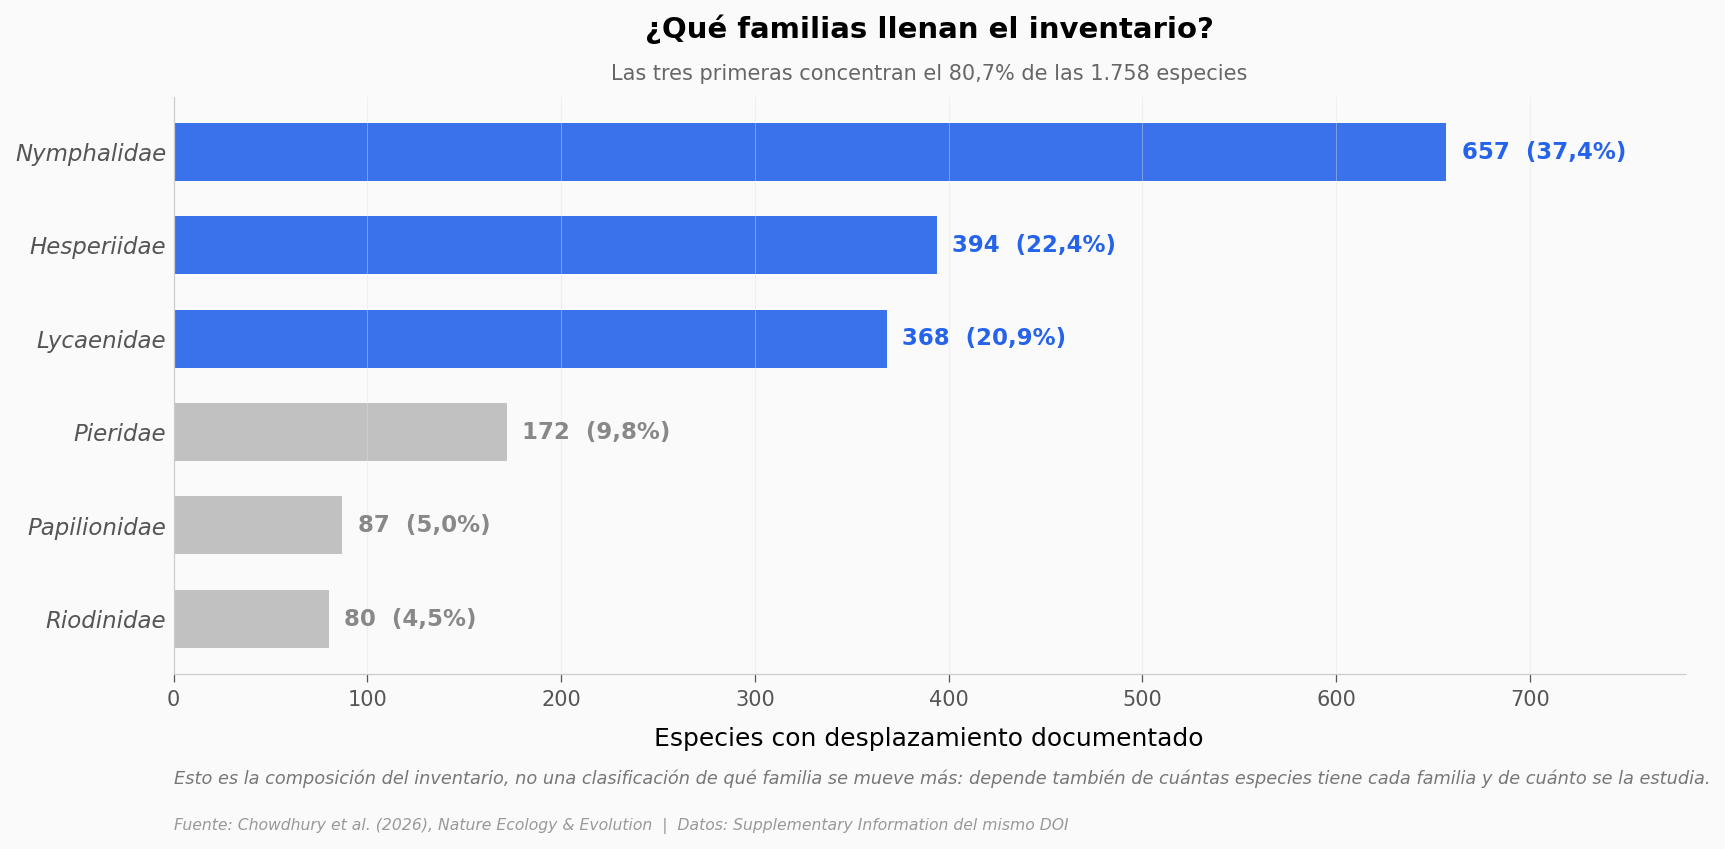

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))

fam = familias.sort_values('n_especies')
y = np.arange(len(fam))
top3 = set(familias.familia.head(3))
colores_fam = [COLOR_DATOS if f in top3 else COLOR_CONTEXTO for f in fam.familia]

ax.barh(y, fam.n_especies, color=colores_fam, alpha=0.9, height=0.62)

for yi, (_, r), c in zip(y, fam.iterrows(), colores_fam):
    ax.text(r.n_especies + 8, yi, f'{r.n_especies}  ({num_es(r.pct_dataset)}%)',
            va='center', ha='left', fontsize=11, fontweight='bold',
            color=c if c != COLOR_CONTEXTO else '#888888')

ax.set_yticks(y)
ax.set_yticklabels(fam.familia, fontsize=11, style='italic')
ax.set_xlim(0, 780)
ax.set_xlabel('Especies con desplazamiento documentado')
ax.grid(axis='x', alpha=0.4)
ax.grid(axis='y', visible=False)

ax.set_title('¿Qué familias llenan el inventario?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Las tres primeras concentran el {num_es(familias.pct_dataset.head(3).sum())}% '
        f'de las {num_es(N_ESPECIES_DATASET, 0)} especies',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.0, -0.19,
        'Esto es la composición del inventario, no una clasificación de qué familia se mueve más: '
        'depende también de cuántas especies tiene cada familia y de cuánto se la estudia.',
        transform=ax.transAxes, fontsize=8.5, color='#777777', style='italic')

ax.text(0.0, -0.27, FUENTE, transform=ax.transAxes,
        fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/familias.png', dpi=200, bbox_inches='tight')
plt.show()

## Este inventario no dice dónde se mueven las mariposas

Dice dónde hay gente contándolas.

Los propios autores lo dejan escrito: los porcentajes por país miden **cobertura de documentación**, no prevalencia real. Y el dataset trae dos maneras de medir el sesgo. Una por región, otra por tipo de fuente.

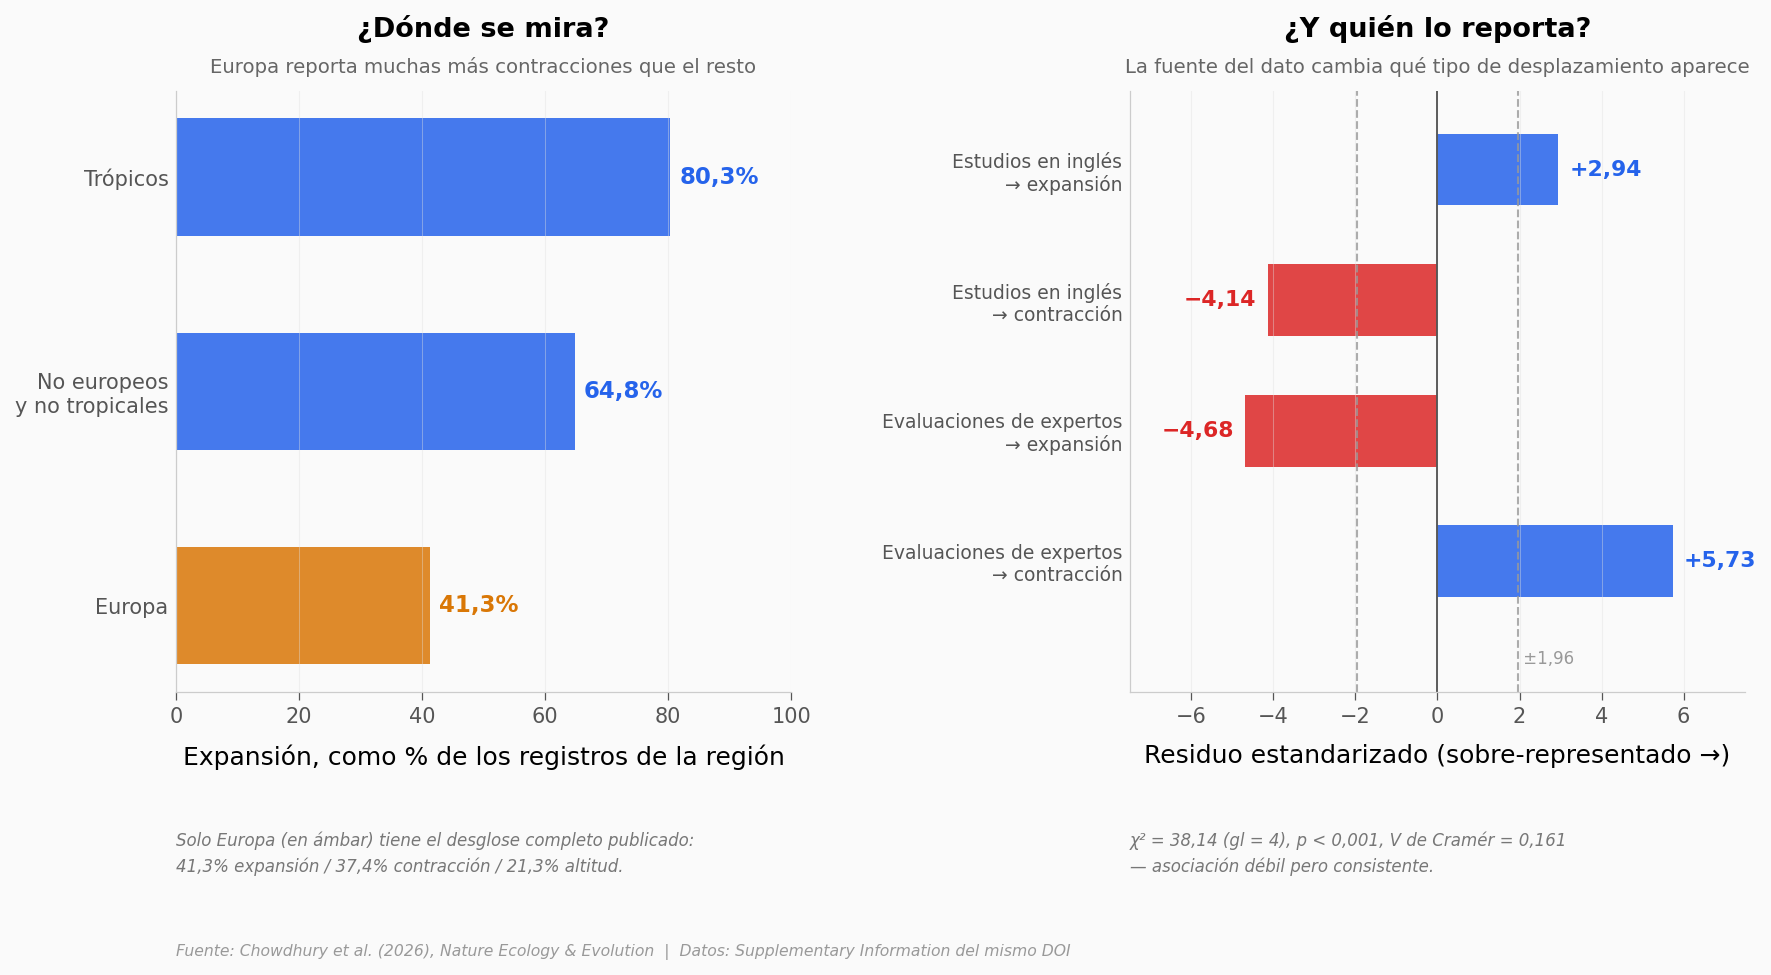

Región  → χ² = 389,13 (gl = 4), p < 0,001, V de Cramér = 0,277  (asociación moderada)
Fuente  → χ² =  38,14 (gl = 4), p < 0,001, V de Cramér = 0,161  (asociación débil)


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2))

# ── Panel izquierdo: expansión como % de los registros de cada región ──
NOMBRE_REGION = {'Tropicos': 'Trópicos',
                 'No europeos y no tropicales': 'No europeos\ny no tropicales',
                 'Europa': 'Europa'}
reg = regional.sort_values('pct_expansion')
y1 = np.arange(len(reg))
# Europa en ámbar: es la única región con el desglose completo publicado
c1 = [COLOR_REFERENCIA if r == 'Europa' else COLOR_DATOS for r in reg.region]

ax1.barh(y1, reg.pct_expansion, color=c1, alpha=0.85, height=0.55)
for yi, (_, r), c in zip(y1, reg.iterrows(), c1):
    ax1.text(r.pct_expansion + 1.5, yi, f'{num_es(r.pct_expansion)}%',
             va='center', fontsize=11, fontweight='bold', color=c)

ax1.set_yticks(y1)
ax1.set_yticklabels([NOMBRE_REGION[t] for t in reg.region], fontsize=10)
ax1.set_xlim(0, 100)
ax1.set_xlabel('Expansión, como % de los registros de la región')
ax1.grid(axis='x', alpha=0.4)
ax1.grid(axis='y', visible=False)
ax1.set_title('¿Dónde se mira?', fontsize=13, fontweight='bold', pad=26)
ax1.text(0.5, 1.03, 'Europa reporta muchas más contracciones que el resto',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax1.text(0.0, -0.30,
         'Solo Europa (en ámbar) tiene el desglose completo publicado:\n'
         '41,3% expansión / 37,4% contracción / 21,3% altitud.',
         transform=ax1.transAxes, fontsize=8, color='#777777', style='italic',
         linespacing=1.5)

# ── Panel derecho: residuos estandarizados por tipo de fuente ──
# Valores reportados en el paper (χ² fuente = 38,14; gl = 4; V de Cramér = 0,161)
res_lab = ['Estudios en inglés\n→ expansión',
           'Estudios en inglés\n→ contracción',
           'Evaluaciones de expertos\n→ expansión',
           'Evaluaciones de expertos\n→ contracción']
res_val = [2.94, -4.14, -4.68, 5.73]
y2 = np.arange(len(res_val))[::-1]
c2 = [COLOR_DATOS if v > 0 else COLOR_ALERTA for v in res_val]

ax2.barh(y2, res_val, color=c2, alpha=0.85, height=0.55)
for yi, v, c in zip(y2, res_val, c2):
    off = 0.28 if v > 0 else -0.28
    etiqueta = ('+' if v > 0 else '−') + num_es(abs(v), 2)
    ax2.text(v + off, yi, etiqueta, va='center',
             ha='left' if v > 0 else 'right', fontsize=10.5,
             fontweight='bold', color=c)

for umbral in (-1.96, 1.96):
    ax2.axvline(umbral, color='#999999', linewidth=1.0, linestyle='--', alpha=0.8)
ax2.axvline(0, color='#555555', linewidth=0.9)
ax2.text(1.96, -0.75, ' ±1,96', fontsize=8, color='#999999', va='center')

ax2.set_yticks(y2)
ax2.set_yticklabels(res_lab, fontsize=9)
ax2.set_xlim(-7.5, 7.5)
ax2.set_ylim(-1.0, len(res_val) - 0.4)
ax2.set_xlabel('Residuo estandarizado (sobre-representado →)')
ax2.grid(axis='x', alpha=0.4)
ax2.grid(axis='y', visible=False)
ax2.set_title('¿Y quién lo reporta?', fontsize=13, fontweight='bold', pad=26)
ax2.text(0.5, 1.03, 'La fuente del dato cambia qué tipo de desplazamiento aparece',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.text(0.0, -0.30,
         'χ² = 38,14 (gl = 4), p < 0,001, V de Cramér = 0,161\n'
         '— asociación débil pero consistente.',
         transform=ax2.transAxes, fontsize=8, color='#777777', style='italic',
         linespacing=1.5)

plt.subplots_adjust(wspace=0.55)
ax1.text(0.0, -0.44, FUENTE, transform=ax1.transAxes,
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sesgo_region_fuente.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Región  → χ² = 389,13 (gl = 4), p < 0,001, V de Cramér = 0,277  (asociación moderada)')
print(f'Fuente  → χ² =  38,14 (gl = 4), p < 0,001, V de Cramér = 0,161  (asociación débil)')

Dos lecturas del panel de la derecha, y las dos importan.

En los estudios publicados en inglés la expansión está sobre-representada (residuo +2,94) y la contracción sub-representada (−4,14). En las evaluaciones de expertos pasa exactamente lo contrario: la contracción salta a +5,73 y la expansión cae a −4,68. La misma pregunta, dos maneras de recoger la respuesta, dos retratos distintos.

Por eso el paper insiste en combinar tipos de datos y en incluir literatura que no está en inglés. Si el inventario se hubiera armado solo con papers anglófonos, el mundo se vería más expansivo de lo que muestra la evidencia combinada.

## ¿Y cuánta evidencia sostiene cada especie?

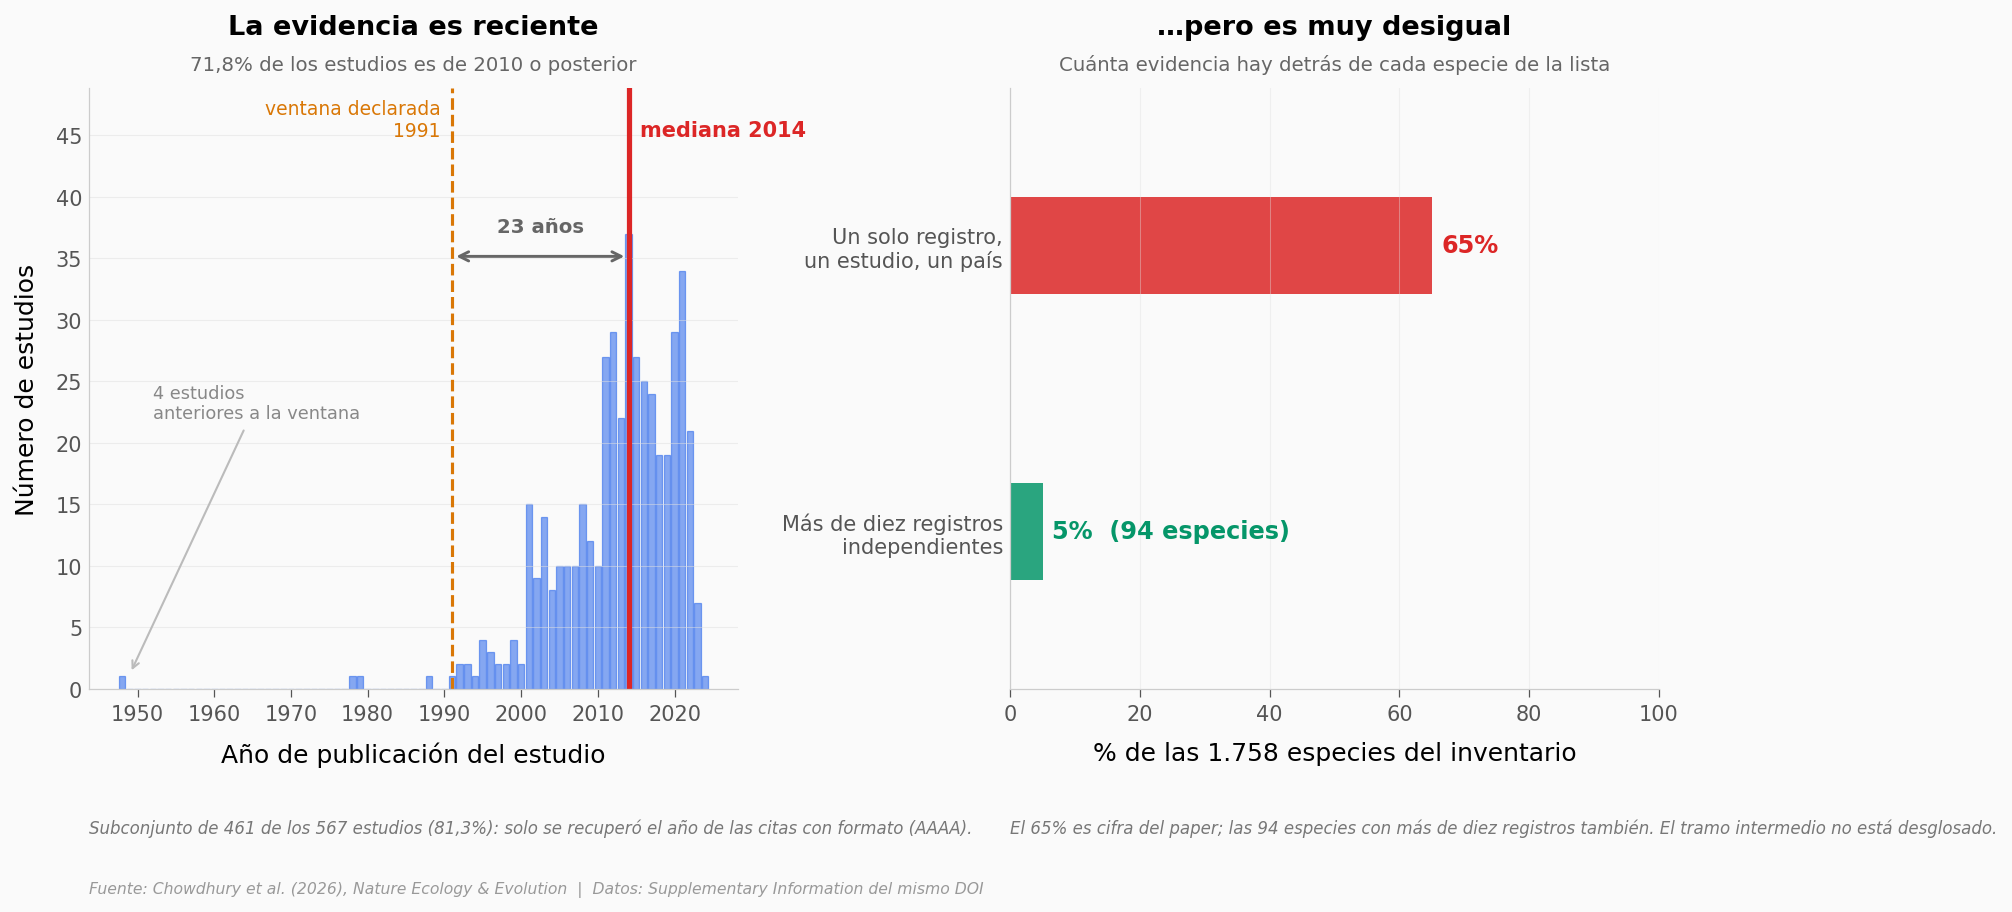

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2))

# ── Panel izquierdo: distribución temporal de los estudios ──
mediana = np.median(anios_flat)
ax1.bar(anios.anio, anios.n_estudios, color=COLOR_DATOS, alpha=0.55,
        edgecolor=COLOR_DATOS, linewidth=0.6, width=0.85)

y_max = anios.n_estudios.max() * 1.32
ax1.set_ylim(0, y_max)

ax1.axvline(mediana, color=COLOR_ALERTA, linewidth=2.5)
ax1.axvline(VENTANA_DECLARADA, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--')

ax1.annotate('', xy=(mediana, y_max * 0.72), xytext=(VENTANA_DECLARADA, y_max * 0.72),
             arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.4))
ax1.text((VENTANA_DECLARADA + mediana) / 2, y_max * 0.76,
         f'{int(mediana - VENTANA_DECLARADA)} años', ha='center', fontsize=9.5,
         color='#666666', fontweight='bold')

ax1.text(mediana + 1.5, y_max * 0.92, f'mediana {int(mediana)}', fontsize=10,
         fontweight='bold', color=COLOR_ALERTA)
ax1.text(VENTANA_DECLARADA - 1.5, y_max * 0.92,
         f'ventana declarada\n{VENTANA_DECLARADA}', fontsize=9, ha='right',
         color=COLOR_REFERENCIA)
ax1.annotate(f'{int((anios_flat < VENTANA_DECLARADA).sum())} estudios\nanteriores a la ventana',
             xy=(1949, 1.2), xytext=(1952, y_max * 0.45), fontsize=8.5, color='#888888',
             arrowprops=dict(arrowstyle='->', color='#BBBBBB', lw=1.0))

ax1.set_xlabel('Año de publicación del estudio')
ax1.set_ylabel('Número de estudios')
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.set_title('La evidencia es reciente', fontsize=13, fontweight='bold', pad=26)
ax1.text(0.5, 1.03,
         f'{num_es(100 * (anios_flat >= ANIO_CORTE).mean())}% de los estudios es de '
         f'{ANIO_CORTE} o posterior',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax1.text(0.0, -0.24,
         'Subconjunto de 461 de los 567 estudios (81,3%): solo se recuperó el año de las '
         'citas con formato (AAAA).',
         transform=ax1.transAxes, fontsize=8, color='#777777', style='italic')

# ── Panel derecho: cuántos registros sostienen a cada especie ──
ev = evidencia[evidencia.metrica.isin(['un_solo_registro_un_estudio_un_pais',
                                       'mas_de_diez_registros_independientes'])]
ev_lab = ['Un solo registro,\nun estudio, un país',
          'Más de diez registros\nindependientes']
y2 = np.arange(len(ev))[::-1]
c2 = [COLOR_ALERTA, COLOR_SECUNDARIO]

ax2.barh(y2, ev.pct_de_1758, color=c2, alpha=0.85, height=0.34)
for yi, (_, r), c, lab in zip(y2, ev.iterrows(), c2, ev_lab):
    extra = '' if str(r.n_especies).startswith('~') else f'  ({r.n_especies} especies)'
    ax2.text(r.pct_de_1758 + 1.5, yi,
             f'{r.pct_de_1758:.0f}%{extra}', va='center', fontsize=11.5,
             fontweight='bold', color=c)

ax2.set_yticks(y2)
ax2.set_yticklabels(ev_lab, fontsize=10)
ax2.set_xlim(0, 100)
ax2.set_ylim(-0.55, len(ev) - 0.45)
ax2.set_xlabel('% de las 1.758 especies del inventario')
ax2.grid(axis='x', alpha=0.4)
ax2.grid(axis='y', visible=False)
ax2.set_title('…pero es muy desigual', fontsize=13, fontweight='bold', pad=26)
ax2.text(0.5, 1.03, 'Cuánta evidencia hay detrás de cada especie de la lista',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.text(0.0, -0.24,
         'El 65% es cifra del paper; las 94 especies con más de diez registros también. '
         'El tramo intermedio no está desglosado.',
         transform=ax2.transAxes, fontsize=8, color='#777777', style='italic')

plt.subplots_adjust(wspace=0.42)
ax1.text(0.0, -0.34, FUENTE, transform=ax1.transAxes,
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/fuerza_evidencia.png', dpi=200, bbox_inches='tight')
plt.show()

### «Inducido» y «asociado» no son la misma palabra

El título del paper dice *climate-induced*: inducido por el clima. El resumen dice *associated with*: asociado al clima. Y el cuerpo lo deja por escrito — estos resultados «resumen la prevalencia de las atribuciones reportadas, no la magnitud del impacto ni el peso causal».

Es la diferencia entre «el clima las movió» y «quien reportó el movimiento anotó el clima como factor». Nadie movió mariposas para ver qué pasaba: alguien leyó 567 estudios y contó qué decían. Cuando el titular sube de *asociado* a *inducido*, nos quedamos con *asociado*.

El 79% del resumen —la cifra de desplazamientos asociados al clima— tampoco es lo que suena. Sale de 278 especies sobre las 352 que tienen alguna amenaza atribuida en el dataset — y esas 352 son el 20,0% de las 1.758. No es «el 79% de los desplazamientos del planeta»: es el 79% de las atribuciones que alguien alcanzó a anotar. De esas 278, hay 163 expansiones, 131 contracciones y 61 cambios de altitud, que otra vez suman más que 278 porque una especie puede tener varios tipos.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El 81,2% de las especies del inventario tiene registros de expansión | ✅ | 1.427 de 1.758, conteo directo. El resumen del paper redondea a 80% (diferencia del 1,5%) |
| El 27,3% contrajo su área y el 21,7% cambió de altitud | ✅ | 480 y 381 sobre 1.758. El paper dice 27% y 22% |
| El inventario cubre cerca del 10% de la diversidad conocida | ✅ | 1.758 de 19.327 = 9,1%. El paper escribe «~10%» — usamos la cifra exacta |
| Nymphalidae aporta el 37,4% de las especies del inventario | ✅ | 657 de 1.758, conteo sobre el listado del Supplementary (1.758 filas, 1.758 especies únicas, 0 duplicados) |
| Nymphalidae es la familia con mayor proporción de especies desplazadas **respecto a su total conocido** | ⚠️ | Es una afirmación del paper (Fig. 1e). El total conocido por familia no aparece ni en el texto ni en el Supplementary: no lo pudimos recomputar y no lo estimamos |
| El 79% de los desplazamientos está asociado al clima | ⚠️ | 278 de 352 especies **con amenaza atribuida**. Esas 352 son el 20,0% del dataset. El porcentaje no aplica al total de 1.758 |
| Europa reporta proporcionalmente muchas más contracciones que los trópicos | ✅ | Composición europea 41,3 / 37,4 / 21,3 frente a 80,3% de expansión en los trópicos. χ² = 389,13 (gl = 4), p < 0,001, V de Cramér = 0,277 — asociación moderada, no fuerte |
| El tipo de fuente cambia qué desplazamiento se reporta | ✅ | Residuos estandarizados: inglés +2,94 expansión / −4,14 contracción; expertos +5,73 contracción / −4,68 expansión. χ² = 38,14 (gl = 4), p < 0,001, V de Cramér = 0,161 — asociación débil |
| El 65% de las especies entra con un solo registro | ✅ | Cifra del paper. Solo 94 especies (5,3% de las 1.758; el paper redondea a 5%) tienen más de diez registros independientes |
| Las mariposas se movieron *tantos* kilómetros o *tantos* metros de altitud | ❌ | El dataset no contiene magnitudes. Los autores declaran que no pudieron compilar tasas estandarizadas de desplazamiento |

> **Limitaciones**
>
> - Los porcentajes por país miden **cobertura de documentación**, no prevalencia real de desplazamientos. Un valor bajo en un país tropical refleja escasez de datos, no ausencia de movimiento — el paper lo dice textualmente.
> - Europa domina el inventario por esfuerzo de monitoreo. El mapa de la evidencia y el mapa del fenómeno no son el mismo mapa.
> - Los tipos de desplazamiento y las amenazas **no son aditivos**: una especie puede aparecer en varias categorías. Ninguna de esas sumas admite leerse como «% del total».
> - Los porcentajes por país del paper vienen en dos bases distintas: sobre la fauna nacional del país y sobre las especies de ese país que tienen desplazamiento documentado. Suecia aparece con un 61% de expansión sobre su fauna nacional y con un 85% de contracción sobre sus especies con desplazamiento: ni la base ni el tipo de desplazamiento coinciden, así que las dos cifras no son comparables entre sí y por eso no las graficamos juntas.
> - La distribución de años cubre 461 de los 567 estudios (81,3%): solo pudimos recuperar el año de las citas con formato (AAAA). La bibliografía está casi toda transliterada, así que el faltante no parece un sesgo de idioma, pero es un faltante.
> - La ventana de búsqueda declarada arranca en 1991 y hay 4 referencias anteriores; la más vieja es de 1948.
> - Todos los porcentajes de este notebook son a nivel de **especie**. El resumen del paper habla de «range shifts», que suena a nivel de registro; el único cálculo reproducible con los datos publicados es por especie.

## Ahora tú

**1. ¿Cambia el retrato si te quedas solo con lo reciente?** El 71,8% de los estudios es de 2010 en adelante. Mueve `ANIO_CORTE` en la celda de configuración y vuelve a correr — ¿cuánto queda si subes el umbral a 2015? ¿Y a 2020?

**2. ¿Qué tan concentrado está el inventario?** Tres familias se llevan el 80,7%. Prueba `familias.pct_dataset.head(n).sum()` con distintos `n`: ¿cuántas familias necesitas para cubrir el 90%?

**3. La cuenta que no cierra.** Los tres tipos suman 2.288 sobre 1.758 especies, y el paper dice que 409 especies tienen más de un tipo. Con esos dos datos se puede deducir cuántas tienen exactamente dos y cuántas tienen los tres. ¿Te sale?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Respuesta a la pregunta 3: la cuenta que no cierra.
#
# Cada especie aporta 1 a la suma por cada tipo de desplazamiento que tiene.
# Si tuviera un solo tipo cada una, la suma sería exactamente 1.758.
# Todo lo que sobra son especies contadas más de una vez.

suma_tipos   = int(tipos.n_especies.sum())
solapamiento = suma_tipos - N_ESPECIES_DATASET      # "conteos extra"
n_varios     = 409                                  # especies con >1 tipo (dato del paper)

# n_dos + n_tres = n_varios          (todas las que tienen más de un tipo)
# n_dos + 2*n_tres = solapamiento    (las de 3 tipos aportan 2 conteos extra)
n_tres = solapamiento - n_varios
n_dos  = n_varios - n_tres
n_uno  = N_ESPECIES_DATASET - n_varios

print(f'Suma de los tres tipos ........ {suma_tipos}')
print(f'Especies del inventario ....... {N_ESPECIES_DATASET}')
print(f'Conteos extra ................. {solapamiento}\n')
print(f'Con UN tipo de desplazamiento . {n_uno:5d}  ({100*n_uno/N_ESPECIES_DATASET:.1f}%)')
print(f'Con DOS tipos ................. {n_dos:5d}  ({100*n_dos/N_ESPECIES_DATASET:.1f}%)')
print(f'Con LOS TRES .................. {n_tres:5d}  ({100*n_tres/N_ESPECIES_DATASET:.1f}%)')
print(f'\nComprobación: {n_uno} + 2×{n_dos} + 3×{n_tres} = '
      f'{n_uno + 2*n_dos + 3*n_tres}  (debe dar {suma_tipos})')
print(f'El paper reporta 1.349 especies con un solo tipo (77%) — '
      f'aquí sale {n_uno}. Cuadra.')

# Ojo: n_dos y n_tres son una deducción nuestra a partir de dos cifras del paper,
# no números que el paper publique. La comprobación de arriba es lo único que los avala.

# ── Pregunta 1: mueve el umbral y mira qué queda ──
print('\nEstudios por umbral temporal (sobre los 461 con año recuperado):')
for umbral in (2000, 2005, 2010, 2015, 2020):
    n = int((anios_flat >= umbral).sum())
    print(f'  desde {umbral}: {n:3d} estudios  ({100*n/len(anios_flat):4.1f}%)')

# ── Pregunta 2: ¿cuántas familias para llegar al 90%? ──
acum = familias.pct_dataset.cumsum()
print('\nCobertura acumulada por familia:')
for i, (fam, a) in enumerate(zip(familias.familia, acum), start=1):
    marca = '  ← supera el 90%' if a >= 90 and acum.iloc[i-2] < 90 else ''
    print(f'  {i} familia(s) [{fam:14s}]: {a:5.1f}%{marca}')

Suma de los tres tipos ........ 2288
Especies del inventario ....... 1758
Conteos extra ................. 530

Con UN tipo de desplazamiento .  1349  (76.7%)
Con DOS tipos .................   288  (16.4%)
Con LOS TRES ..................   121  (6.9%)

Comprobación: 1349 + 2×288 + 3×121 = 2288  (debe dar 2288)
El paper reporta 1.349 especies con un solo tipo (77%) — aquí sale 1349. Cuadra.

Estudios por umbral temporal (sobre los 461 con año recuperado):
  desde 2000: 436 estudios  (94.6%)
  desde 2005: 388 estudios  (84.2%)
  desde 2010: 331 estudios  (71.8%)
  desde 2015: 206 estudios  (44.7%)
  desde 2020:  92 estudios  (20.0%)

Cobertura acumulada por familia:
  1 familia(s) [Nymphalidae   ]:  37.4%
  2 familia(s) [Hesperiidae   ]:  59.8%
  3 familia(s) [Lycaenidae    ]:  80.7%
  4 familia(s) [Pieridae      ]:  90.5%  ← supera el 90%
  5 familia(s) [Papilionidae  ]:  95.4%
  6 familia(s) [Riodinidae    ]: 100.0%


## Fuentes

**Paper**: [Extensive climate-induced range shifts in butterflies across the globe](https://doi.org/10.1038/s41559-026-03117-y)  
*Nature Ecology & Evolution, 2026-08-05 · acceso abierto*

**Supplementary Material**: [Supplementary Information, secciones 1–3](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41559-026-03117-y/MediaObjects/41559_2026_3117_MOESM1_ESM.pdf)  
*Mismo DOI — de aquí salen el listado de las 1.758 especies con su familia y el año de los 461 estudios*

*22 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducibilidad:** todo el código de este notebook corre sobre los CSV de la carpeta `datos/`, extraídos del texto del paper (acceso abierto) y de su Supplementary Information.
**Licencia:** el código de este repositorio es de uso libre; los datos pertenecen a sus autores originales y se citan arriba.
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)